# This code does everything needed for weekly 1:1 coaching report

I used gspread&pandas libraries with python. FIrstly, I created Google Cloud project, then enabled Google Sheets API, created Google Service account and used
its JSON key for sharing access with my python-gspread-service.

In [5]:
### Start of the app

import gspread
import pandas as pd
from gspread_dataframe import set_with_dataframe
import numpy as np
import matplotlib.pyplot as plt
# 1. Authenticate using JSON key
gc = gspread.service_account(filename="python-project.json")

# 2. Open the Google Sheet
sh = gc.open_by_url("https://docs.google.com/spreadsheets/d/1-xRLlDx4bo4233eCq-4C4iKYbdn49qIMl_xk6tG6vJ0/edit?usp=sharing") #this is the url of the table

# 3. Select the specific worksheet (if there are many)
worksheet = sh.worksheet("event-data-from-20250301-to-20260130")


### Collect + clean and analyse data.

In [6]:
df = pd.DataFrame(worksheet.get_all_records())
print(df.columns)


Index(['Event Type Name', 'Start Date & Time', 'End Date & Time', 'Canceled',
       'Canceled By', 'Event UUID'],
      dtype='str')


#### We need to organize our date data. Now our date looks like this:

In [8]:
df["Start Date & Time"].head()

0    2025-03-11 4:45 PM
1    2025-03-03 3:00 PM
2    2025-03-03 3:45 PM
3    2025-03-06 4:15 PM
4    2025-03-03 3:30 PM
Name: Start Date & Time, dtype: str

#### We need to parse it in pandas datetime timestamp to be able to easily use it in the future.

In [10]:
df["Start Date & Time"] = pd.to_datetime(df["Start Date & Time"], errors="coerce") #tries to parse each string into a real timestamp


In [ ]:
df["Start Date & Time"].dt.weekday.head() #0-6, where 0 is Monday and 6 is Sunday

0    1
1    0
2    0
3    3
4    0
Name: Start Date & Time, dtype: int32

#### We need to find each Sunday of the week

In [ ]:
df["week"] = df["Start Date & Time"] - pd.to_timedelta( #subtract a timedelta (absolute difference in times) from a datetime
    (df["Start Date & Time"].dt.weekday + 1) # from 1 to 7
    % 7,#how many days to go back to reach Sunday:
    unit="D") # converts numbers into time intervals like 1day, 2 days

#df["week"] = df["Start Date & Time"].dt.to_period("W-MON").dt.start_time

df["week"] = df["week"].dt.normalize() #get rid of time part

#### The table we are plotting:

In [ ]:
weekly_counts = (
    df.groupby(["week", "Event Type Name"])
      .size()
      .reset_index(name="count")
)

cutoff = pd.Timestamp("2025-08-31")

weekly_counts_since_september = weekly_counts[weekly_counts["week"] >= cutoff].copy()


,Event Type Name,count
0,BC/AB: Volunteer Success Program,21
1,ON: Volunteer Success Program,22


In [31]:
import plotly.graph_objects as go
import pandas as pd

fig = go.Figure() # empty figure


for event_type, group in weekly_counts_since_september.groupby("Event Type Name"): #two plots

    # always sort by week so lines connect correctly
    group = group.sort_values("week")

    # Different text positions for different event types
    if event_type == "BC/AB: Volunteer Success Program":
        text_pos = "top center"
    else:
        text_pos = "bottom center"

   # one trace per event type
    fig.add_trace(go.Scatter(
        x=group["week"],          # x axis dates
        y=group["count"],         # y axis values
        mode="lines+markers+text", # lines, points, and text
        name=event_type,          # legend label
        text=group["count"],      # numbers displayed
        marker=dict(size=8),    # size of circles
        textposition=text_pos     # above/below points
    ))

#list of all weeks to set x axis ticks
all_weeks = (
    weekly_counts_since_september["week"]
    .sort_values()
    .unique()
)
all_weeks = pd.to_datetime(all_weeks)


fig.update_layout(
    title="Weekly Trend Since September",
    xaxis_title="Week of Start Date",
    yaxis_title="Count of Invitees",
    legend_title="Event Type",
    width=1000,
    height=600,
    yaxis=dict(range=[0, 80])  # same as ax.set_ylim in matplotlib
)

# Customize x axis ticks
fig.update_xaxes(
    tickvals=all_weeks,                       # force every week
    ticktext=[d.strftime("%b %d") for d in all_weeks],  # Jan 14 format
    tickangle=45                              # rotate labels
)

fig.show()


## Event counts for chosen week

In [33]:
start = "2026-01-25"
end   = "2026-01-31"

mask = (df["Start Date & Time"] >= start) & (df["Start Date & Time"] <= end)
df_week = df[mask]

event_counts = (
    df_week["Event Type Name"]
      .value_counts()

)

print(event_counts)
event_counts.index

Event Type Name
ON: Volunteer Success Program       58
BC/AB: Volunteer Success Program     3
Name: count, dtype: int64


Index(['ON: Volunteer Success Program', 'BC/AB: Volunteer Success Program'], dtype='str', name='Event Type Name')

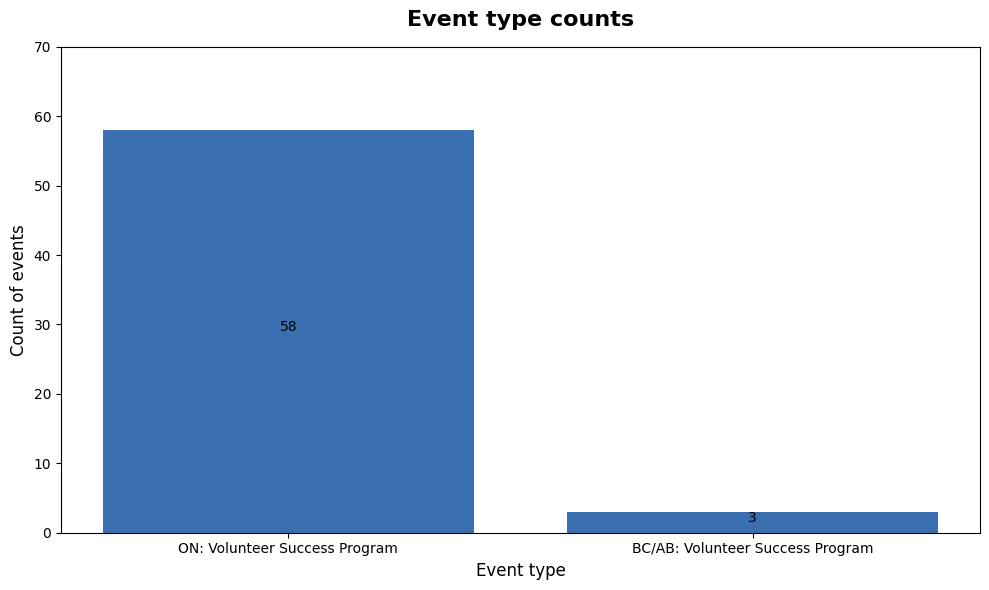

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    event_counts.index, event_counts.values,
    color="#3A6FB0",
)
for x, y in zip(event_counts.index, event_counts.values):
    ax.text(x, int(y) / 2, str(y), ha="center", fontsize=10)
ax.set_ylim(bottom=0, top=70)
ax.set_title("Event type counts", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Event type", fontsize=12)
ax.set_ylabel("Count of events", fontsize=12)
plt.tight_layout()
plt.show()

## Running total

In [ ]:
# create running total per event type
weekly_counts_since_september["running_total"] = (
    weekly_counts_since_september
    .groupby("Event Type Name")["count"]
    .cumsum()
)


33      23
34      19
35      51
36      46
37      90
38      76
39     101
40     114
42     171
41     128
43     156
44     246
45     188
46     317
47     220
48     392
49     237
50     456
51     250
52     533
54     591
53     266
55     280
56     668
57     288
58     744
59     296
60     807
61     303
62     854
64     894
63     306
65     314
66     925
67     318
68     979
69     321
70    1037
71     324
72    1107
74    1133
73     326
75    1137
Name: running_total, dtype: int64

In [40]:
fig = go.Figure()
for event_type, group in weekly_counts_since_september.groupby("Event Type Name"):

    # Always sort by week
    group = group.sort_values("week")

    # Add line + markers + labels
    fig.add_trace(go.Scatter(
        x=group["week"],                
        y=group["running_total"],        
        mode="lines+markers+text",       # line + dots + numbers
        name=event_type,                 # legend name
        text=group["running_total"],     # numbers near points
        textposition="top center"        # label position
    ))

# Layout styling
fig.update_layout(
    title="Weekly Trend Running Total Since Mar 1, 2025",
    xaxis_title="Week of Start Date",
    yaxis_title="Running Sum of Count of Invitees",
    width=1200,
    height=600,
    legend_title="Event Type"
)

all_weeks = pd.to_datetime(
    weekly_counts_since_september["week"].sort_values().unique()
)

fig.update_xaxes(
    tickvals=all_weeks,
    ticktext=[d.strftime("%b %d") for d in all_weeks],
    tickangle=45
)

fig.update_yaxes(range=[0, 1400])

# Show chart
fig.show()

## Cancellations count

In [44]:
cancelled_counts = df_week[df_week["Canceled"] == "TRUE"]

counts = (
    cancelled_counts.groupby(["Event Type Name", "Canceled By"])
    .size()
    .unstack(fill_value=0)
)
counts

Canceled By,Invitee
Event Type Name,
ON: Volunteer Success Program,14


In [46]:
fig = go.Figure()
for canceled_by in counts.columns:
    fig.add_trace(go.Bar(
        x=counts.index,
        y=counts[canceled_by],
        name=canceled_by,
        text=counts[canceled_by],
        textposition='auto'
    ))
fig.update_layout(
    barmode='stack',
    title="Cancellation Type Counts",
    xaxis_title="Event type",
    yaxis_title="Count of cancellations",
    width=1000,
    height=600,
    legend_title="Canceled By",
    
)


fig.update_yaxes(range=[0, 30])

# Show chart
fig.show()

## Events by day

In [48]:
df_week["timestamp"] = pd.to_datetime(df_week["Start Date & Time"])
# Extracting weekday and indexing, so that Sunday is 0
df_week["weekday"] = df_week["timestamp"].dt.day_name()
# remap: Sunday first
order_map = {
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4,
    "Thursday": 5, "Friday": 6, "Saturday": 7
}
df_week["weekday_order"] = df_week["weekday"].map(order_map)


In [70]:
counts = (
    df_week
    .groupby(["Event Type Name", "weekday"])
    .size()
    .unstack(fill_value=0)
)
order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

counts = counts.reset_index()

counts_long = counts.melt(
    id_vars="Event Type Name",
    var_name="weekday",
    value_name="count"
)
counts_long

,Event Type Name,weekday,count
0,BC/AB: Volunteer Success Program,Friday,0
1,ON: Volunteer Success Program,Friday,9
2,BC/AB: Volunteer Success Program,Monday,1
3,ON: Volunteer Success Program,Monday,14
4,BC/AB: Volunteer Success Program,Sunday,1
5,ON: Volunteer Success Program,Sunday,7
6,BC/AB: Volunteer Success Program,Thursday,0
7,ON: Volunteer Success Program,Thursday,9
8,BC/AB: Volunteer Success Program,Tuesday,1
9,ON: Volunteer Success Program,Tuesday,5


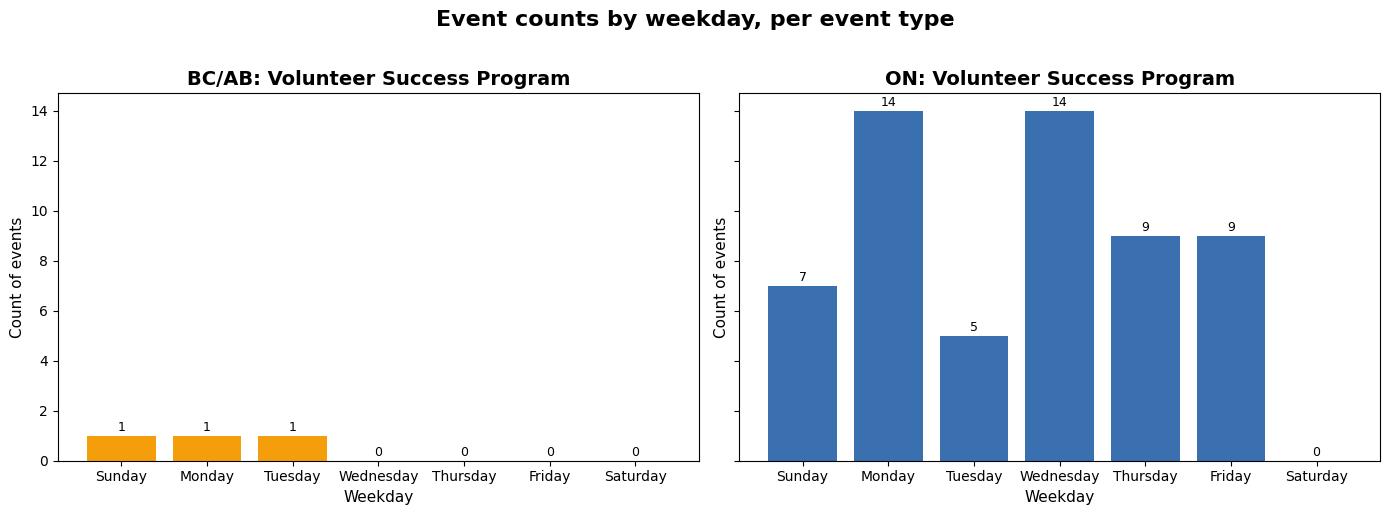

In [50]:
n_events = len(counts)
fig, axes = plt.subplots(
    1, n_events,              # 1 row, N columns
    figsize=(7 * n_events, 5),
    sharey=True
)

# If there is only one event type, axes is not an array
if n_events == 1:
    axes = [axes]
colors = ["#F59E0B", "#3A6FB0"]
for i, (ax, (event_name, row)) in enumerate(zip(axes, counts.iterrows())):
    # row.index -> weekdays, row.values -> counts
    color = colors[i % len(colors)]

    ax.bar(row.index, row.values, color=color)
    for x, y in zip(row.index, row.values):
        ax.text(x, y + 0.2, str(int(y)), ha="center", fontsize=9)

    ax.set_title(event_name, fontsize=14, weight="bold")
    ax.set_xlabel("Weekday", fontsize=11)
    ax.set_ylabel("Count of events", fontsize=11)

fig.suptitle("Event counts by weekday, per event type", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [84]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


counts_long = counts_long.sort_values("weekday")

# Create subplots: 1 row, 2 columns
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=counts_long["Event Type Name"].unique(),
    shared_yaxes=True
)

# Get unique event types
event_types = counts_long["Event Type Name"].unique()

# Add bar traces for each event type
for i, event_type in enumerate(event_types):

    group = counts_long[counts_long["Event Type Name"] == event_type]

    fig.add_trace(
        go.Bar(
            x=group["weekday"],
            y=group["count"],
            text=group["count"],
            textposition="outside",
            
        ),
        row=1,
        col=i+1   # col 1 then col 2
    )


fig.update_layout(
    title="Event counts by weekday, per event type",
    width=1100,
    height=450,
    showlegend=False
)

# Y axis titles for both subplots
fig.update_yaxes(title_text="Count of events",)
fig.update_yaxes(title_text="Count of events")

# X axis title
fig.update_xaxes(title_text="Weekday", row=1, col=1)
fig.update_xaxes(title_text="Weekday", row=1, col=2)

fig.show()
